# Clustering con K-Means

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

sns.set_style('whitegrid')
np.random.seed(42)

---
### Generación de datos de clientes simulados
---

In [2]:
# Simulamos datos de clientes con 2 features: gasto promedio y frecuencia de compra
X, y_true = make_blobs(n_samples=300, centers=4, n_features=2, 
                       cluster_std=0.60, random_state=42)

# Transformamos para que tenga sentido como datos de clientes
X[:, 0] = X[:, 0] * 20 + 100  # Gasto promedio ($50-$250)
X[:, 1] = X[:, 1] * 2 + 10     # Frecuencia de compra (5-20 veces/mes)

# Creamos un DataFrame
df = pd.DataFrame(X, columns=['gasto_promedio', 'frecuencia_compra'])
df['gasto_promedio'] = df['gasto_promedio'].clip(lower=20)  # Minimo realista
df['frecuencia_compra'] = df['frecuencia_compra'].clip(lower=1).round(1)

print(f"Dataset generado: {df.shape[0]} clientes, {df.shape[1]} features")
display(df.head(10))

Dataset generado: 300 clientes, 2 features


,gasto_promedio,frecuencia_compra
0,20.000000,23.6
1,20.000000,24.2
2,59.686586,26.6
3,20.000000,1.0
4,20.000000,23.4
5,20.000000,1.0
6,194.875748,14.4
7,20.000000,1.0
8,44.065957,27.8
9,178.501935,14.7


---
### Análisis Exploratorio
---

In [3]:
df.describe()

,gasto_promedio,frecuencia_compra
count,300.000000,300.000000
mean,70.413931,16.877000
std,72.684243,10.574816
min,20.000000,1.000000
25%,20.000000,8.950000
50%,20.000000,20.250000
75%,92.813301,26.300000
max,220.573480,31.000000


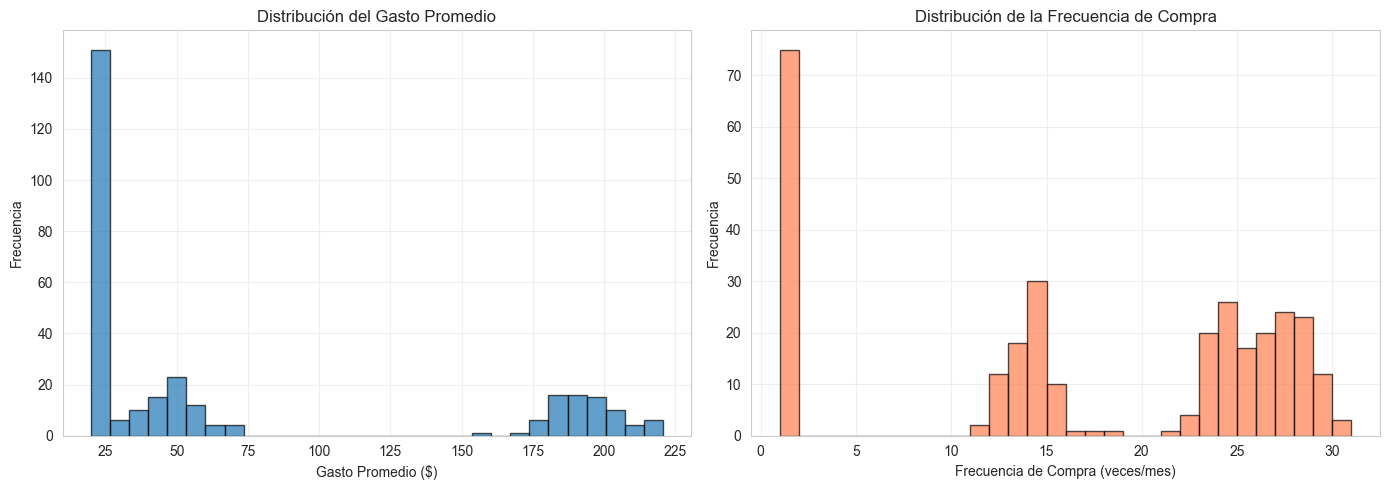

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['gasto_promedio'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Gasto Promedio ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del Gasto Promedio')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['frecuencia_compra'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Frecuencia de Compra (veces/mes)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de la Frecuencia de Compra')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

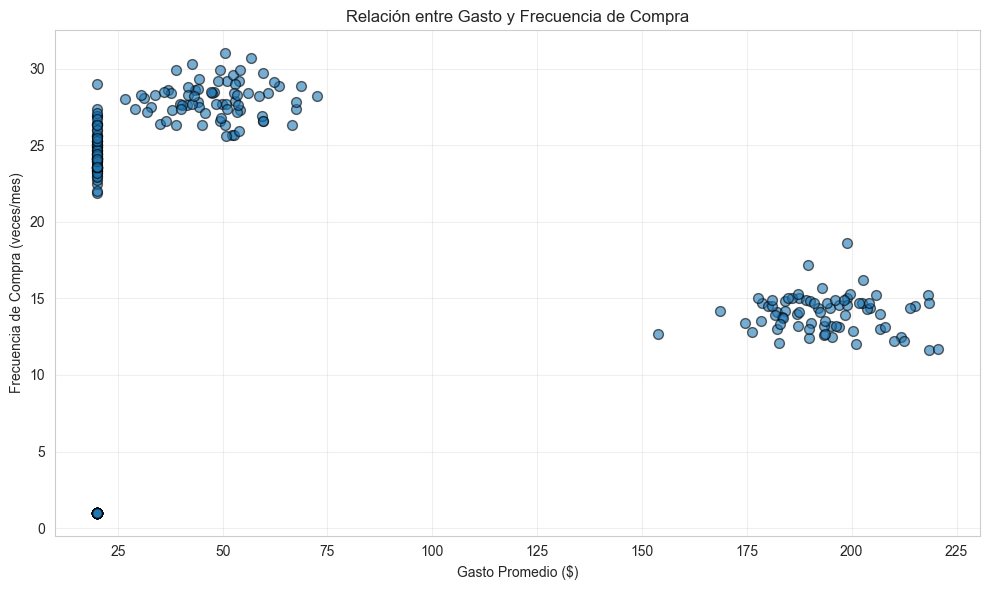

In [5]:
plt.figure(figsize=(10, 6))
plt.scatter(df['gasto_promedio'], df['frecuencia_compra'], 
            alpha=0.6, edgecolors='k', s=50)
plt.xlabel('Gasto Promedio ($)')
plt.ylabel('Frecuencia de Compra (veces/mes)')
plt.title('Relación entre Gasto y Frecuencia de Compra')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
### Normalización de features
---

In [6]:
# K-Means es sensible a la escala, normalizamos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['gasto_promedio', 'frecuencia_compra']])

print("Features normalizadas:")
print(f"Media: {X_scaled.mean(axis=0)}")
print(f"Std: {X_scaled.std(axis=0)}")

Features normalizadas:
Media: [8.28966525e-17 1.00660221e-16]
Std: [1. 1.]


---
### Método del Codo: ¿Cuántos clusters?
---

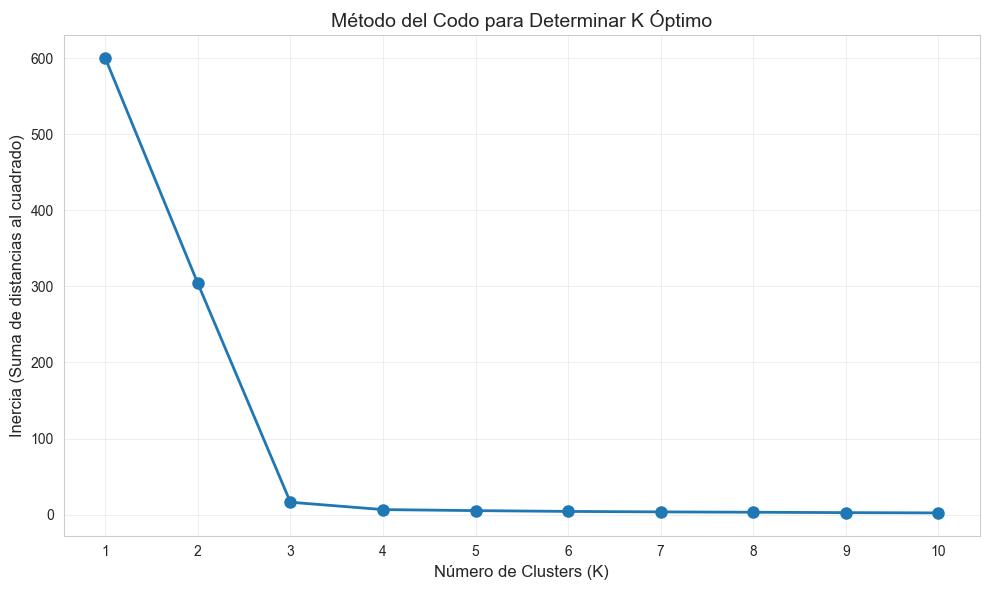

In [16]:
inercias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inercias, marker='o', linewidth=2, markersize=8)
plt.xlabel('Número de Clusters (K)', fontsize=12)
plt.ylabel('Inercia (Suma de distancias al cuadrado)', fontsize=12)
plt.title('Método del Codo para Determinar K Óptimo', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.show()

---
### Silhouette Score: Otra métrica para elegir K
---

K=2: Silhouette Score = 0.616
K=3: Silhouette Score = 0.897
K=4: Silhouette Score = 0.796
K=5: Silhouette Score = 0.667
K=6: Silhouette Score = 0.599
K=7: Silhouette Score = 0.571
K=8: Silhouette Score = 0.570
K=9: Silhouette Score = 0.564
K=10: Silhouette Score = 0.576


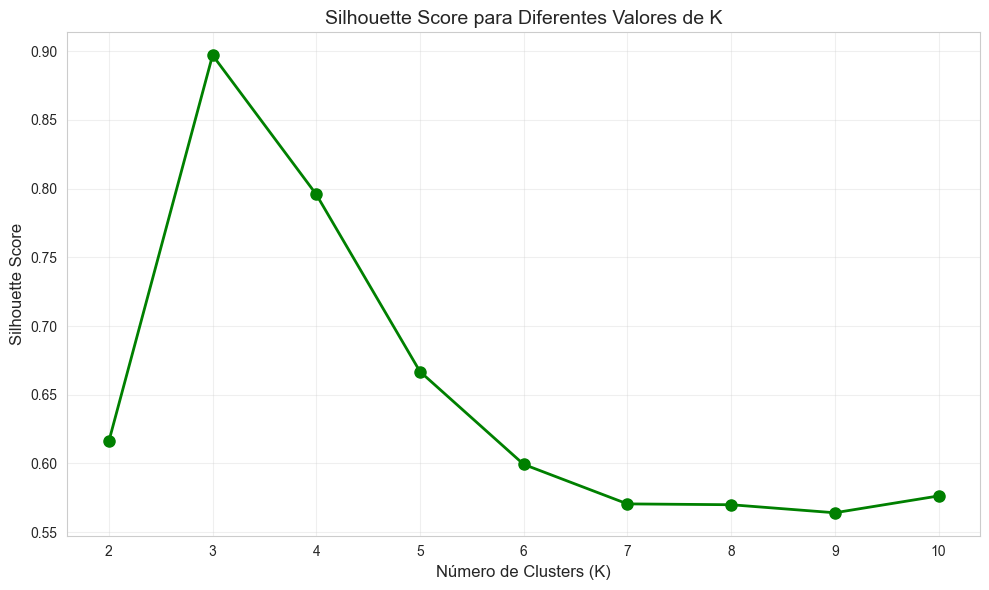

In [17]:
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, clusters)
    silhouette_scores.append(score)
    print(f"K={k}: Silhouette Score = {score:.3f}")

plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, marker='o', linewidth=2, markersize=8, color='green')
plt.xlabel('Número de Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score para Diferentes Valores de K', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.show()

best_k = list(K_range)[np.argmax(silhouette_scores)]

---
### Aplicar K-Means con K óptimo
---

In [18]:
# Usamos K=3 basado en los resultados anteriores
k_optimo = 3

kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=20)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Centroides en escala original
centroides_scaled = kmeans.cluster_centers_
centroides_original = scaler.inverse_transform(centroides_scaled)

print(f"Clusters asignados para K={k_optimo}")
print(f"\nDistribución de clientes por cluster:")
print(df['cluster'].value_counts().sort_index())

Clusters asignados para K=3

Distribución de clientes por cluster:
cluster
0    150
1     75
2     75
Name: count, dtype: int64


---
### Visualización de los clusters
---

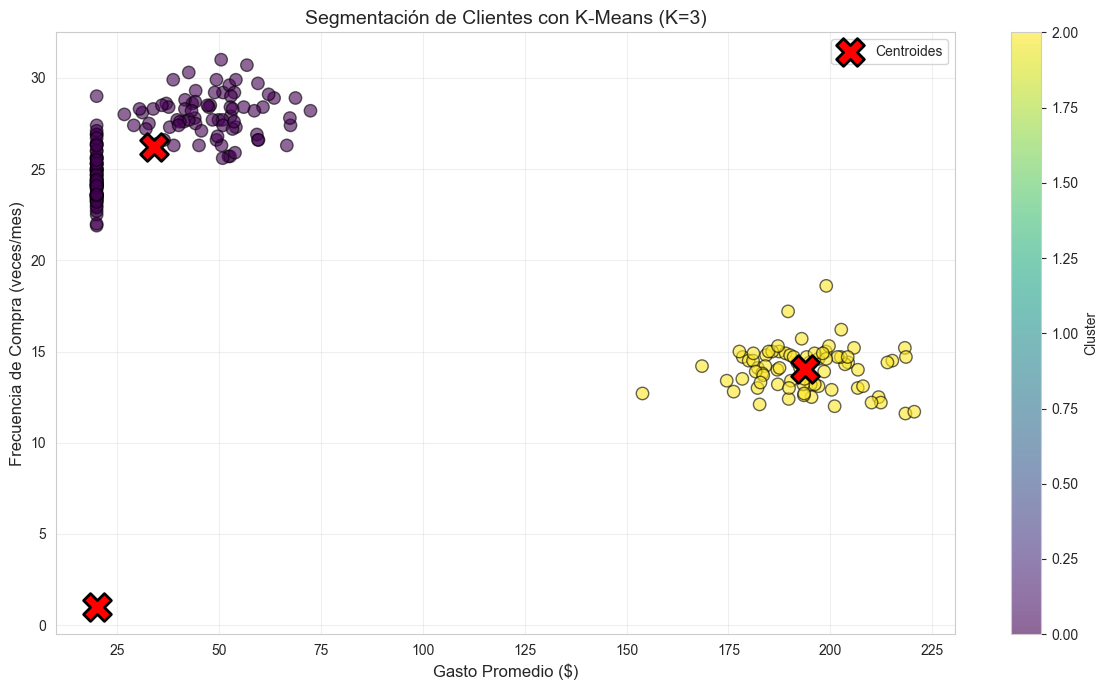

In [19]:
plt.figure(figsize=(12, 7))
scatter = plt.scatter(df['gasto_promedio'], df['frecuencia_compra'], 
                      c=df['cluster'], cmap='viridis', 
                      alpha=0.6, edgecolors='k', s=80)
plt.scatter(centroides_original[:, 0], centroides_original[:, 1],
            marker='X', s=400, c='red', edgecolors='black', linewidths=2,
            label='Centroides')

plt.xlabel('Gasto Promedio ($)', fontsize=12)
plt.ylabel('Frecuencia de Compra (veces/mes)', fontsize=12)
plt.title(f'Segmentación de Clientes con K-Means (K={k_optimo})', fontsize=14)
plt.colorbar(scatter, label='Cluster')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
### Análisis de centroides: ¿Qué caracteriza a cada cluster?
---

In [20]:
# Estadísticas por cluster
cluster_stats = df.groupby('cluster')[['gasto_promedio', 'frecuencia_compra']].mean()
cluster_stats['cantidad_clientes'] = df.groupby('cluster').size()
cluster_stats = cluster_stats.round(2)

print("Características promedio de cada cluster:\n")
display(cluster_stats)

# Interpretación
print("\n" + "="*60)
print("INTERPRETACIÓN DE LOS SEGMENTOS:")
print("="*60)

for cluster_id in range(k_optimo):
    gasto = cluster_stats.loc[cluster_id, 'gasto_promedio']
    freq = cluster_stats.loc[cluster_id, 'frecuencia_compra']
    cant = cluster_stats.loc[cluster_id, 'cantidad_clientes']
    
    print(f"\nCluster {cluster_id}:")
    print(f"  - Gasto promedio: ${gasto:.2f}")
    print(f"  - Frecuencia: {freq:.1f} veces/mes")
    print(f"  - Cantidad de clientes: {int(cant)}")
    
    # Etiqueta descriptiva
    if gasto < 80 and freq < 8:
        label = "Clientes Ocasionales (bajo gasto, baja frecuencia)"
    elif gasto > 150 and freq > 12:
        label = "Clientes VIP (alto gasto, alta frecuencia)"
    elif gasto > 100 and freq < 10:
        label = "Compradores de Alto Ticket (alto gasto, poca frecuencia)"
    elif gasto < 100 and freq > 10:
        label = "Clientes Frecuentes (bajo gasto, alta frecuencia)"
    else:
        label = "Clientes Regulares (gasto y frecuencia medios)"
    
    print(f"  → {label}")

Características promedio de cada cluster:



,gasto_promedio,frecuencia_compra,cantidad_clientes
cluster,,,
0,33.96,26.24,150
1,20.00,1.00,75
2,193.74,14.03,75



INTERPRETACIÓN DE LOS SEGMENTOS:

Cluster 0:
  - Gasto promedio: $33.96
  - Frecuencia: 26.2 veces/mes
  - Cantidad de clientes: 150
  → Clientes Frecuentes (bajo gasto, alta frecuencia)

Cluster 1:
  - Gasto promedio: $20.00
  - Frecuencia: 1.0 veces/mes
  - Cantidad de clientes: 75
  → Clientes Ocasionales (bajo gasto, baja frecuencia)

Cluster 2:
  - Gasto promedio: $193.74
  - Frecuencia: 14.0 veces/mes
  - Cantidad de clientes: 75
  → Clientes VIP (alto gasto, alta frecuencia)


---
### Visualización de distribuciones por cluster
---

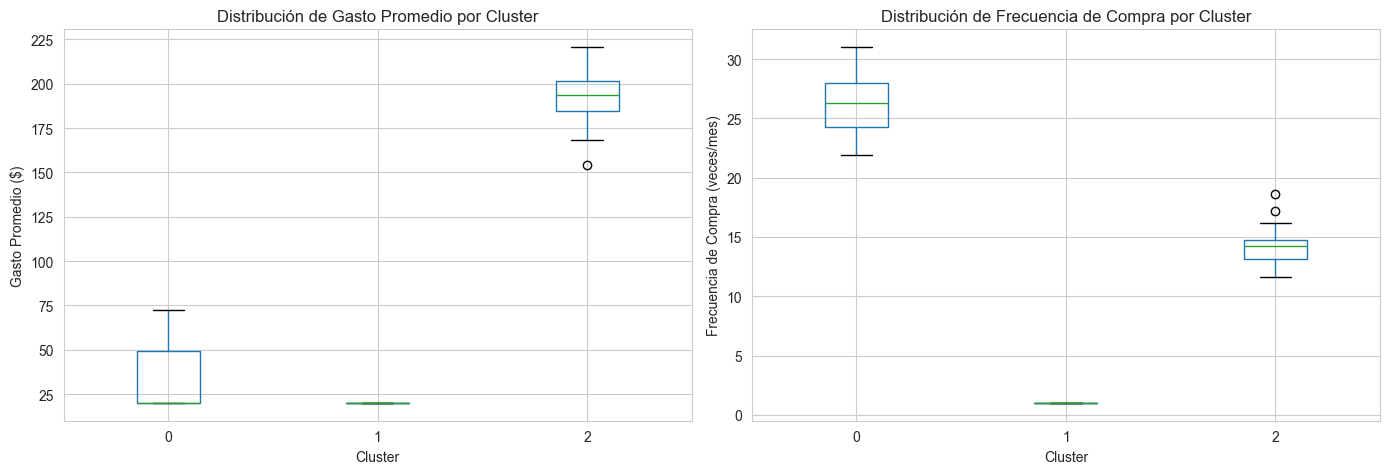

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gasto promedio por cluster
df.boxplot(column='gasto_promedio', by='cluster', ax=axes[0])
axes[0].set_title('Distribución de Gasto Promedio por Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Gasto Promedio ($)')

# Frecuencia de compra por cluster
df.boxplot(column='frecuencia_compra', by='cluster', ax=axes[1])
axes[1].set_title('Distribución de Frecuencia de Compra por Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Frecuencia de Compra (veces/mes)')

plt.suptitle('')
plt.tight_layout()
plt.show()

---
### Análisis de Silhouette por cluster
---

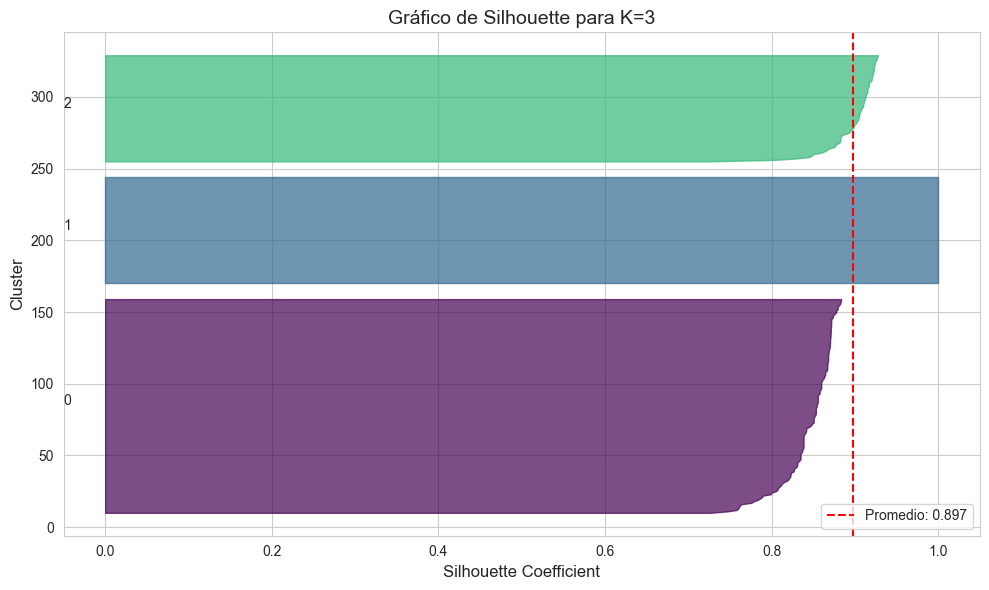


Interpretación:
- Valores cercanos a 1: bien asignados
- Valores cercanos a 0: en el límite entre clusters
- Valores negativos: probablemente mal asignados


In [22]:
# Silhouette score por observación
silhouette_vals = silhouette_samples(X_scaled, df['cluster'])
df['silhouette'] = silhouette_vals

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10

for cluster_id in range(k_optimo):
    cluster_silhouette_vals = silhouette_vals[df['cluster'] == cluster_id]
    cluster_silhouette_vals.sort()
    
    size_cluster = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster
    
    color = plt.cm.viridis(float(cluster_id) / k_optimo)
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                      0, cluster_silhouette_vals,
                      facecolor=color, edgecolor=color, alpha=0.7)
    
    ax.text(-0.05, y_lower + 0.5 * size_cluster, str(cluster_id))
    y_lower = y_upper + 10

ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_title(f'Gráfico de Silhouette para K={k_optimo}', fontsize=14)
ax.axvline(x=silhouette_score(X_scaled, df['cluster']), 
           color="red", linestyle="--", label=f"Promedio: {silhouette_score(X_scaled, df['cluster']):.3f}")
ax.legend()
plt.tight_layout()
plt.show()

print("\nInterpretación:")
print("- Valores cercanos a 1: bien asignados")
print("- Valores cercanos a 0: en el límite entre clusters")
print("- Valores negativos: probablemente mal asignados")

---
### Comparación: ¿Qué pasa con otros valores de K?
---

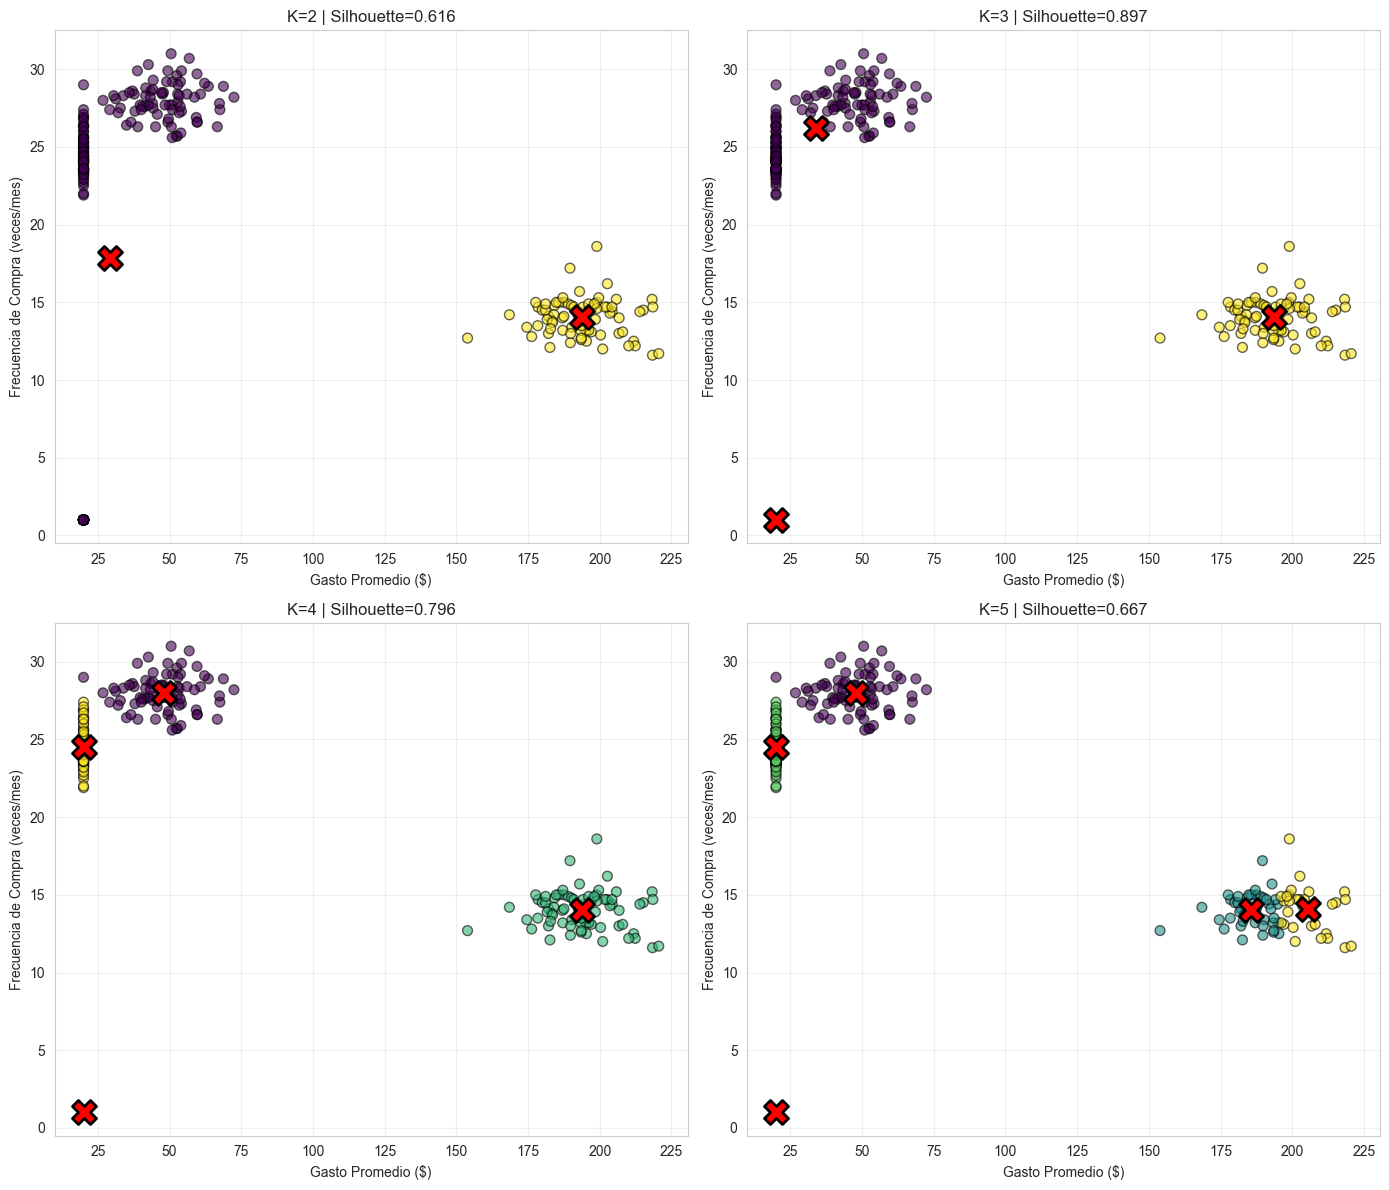


Pregunta: ¿Cuál parece la mejor segmentación visualmente?
Considerá tanto el Silhouette Score como la interpretabilidad del negocio.


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

K_comparar = [2, 3, 4, 5]

for idx, k in enumerate(K_comparar):
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters_temp = kmeans_temp.fit_predict(X_scaled)
    centroides_temp = scaler.inverse_transform(kmeans_temp.cluster_centers_)
    silhouette_avg = silhouette_score(X_scaled, clusters_temp)
    
    scatter = axes[idx].scatter(df['gasto_promedio'], df['frecuencia_compra'],
                                c=clusters_temp, cmap='viridis',
                                alpha=0.6, edgecolors='k', s=50)
    axes[idx].scatter(centroides_temp[:, 0], centroides_temp[:, 1],
                      marker='X', s=300, c='red', edgecolors='black', linewidths=2)
    
    axes[idx].set_xlabel('Gasto Promedio ($)')
    axes[idx].set_ylabel('Frecuencia de Compra (veces/mes)')
    axes[idx].set_title(f'K={k} | Silhouette={silhouette_avg:.3f}')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPregunta: ¿Cuál parece la mejor segmentación visualmente?")
print("Considerá tanto el Silhouette Score como la interpretabilidad del negocio.")